# Edmonds-Karp

Implementação visual do algoritmo de Edmonds-Karp em Python;
Calcula o fluxo máximo em uma rede de fluxo e apresenta, passo a passo, os caminhos aumentantes encontrados via BFS, com animação gráfica do grafo a cada iteração.   

In [19]:
# Célula 1 — Importações

from collections import deque # Deque para BFS
import networkx as nx # Para visualização do grafo
import matplotlib.pyplot as plt # Para plotagem
import time # Para controle de tempo na animação
from IPython.display import clear_output # Para limpar a saída na animação

In [20]:
# Célula 2 — BFS
'''
    Implementação da busca em largura (BFS) para encontrar um caminho aumentante.
    Revisão: BFS (Breadth-First Search) é um algoritmo de busca em grafos que explora os vértices de um grafo em camadas, começando pelo vértice de origem e visitando todos os seus vizinhos antes de passar para os vizinhos dos vizinhos. No contexto do algoritmo de Edmonds-Karp, a BFS é usada para encontrar um caminho aumentante no grafo residual, ou seja, um caminho do vértice de origem ao vértice de destino onde ainda há capacidade disponível para enviar fluxo. A BFS é eficiente para esse propósito porque garante que o caminho encontrado seja o mais curto em termos de número de arestas, o que ajuda a limitar o número total de iterações do algoritmo.  
'''
def bfs(capacidade, fluxo, origem, destino, pai, adjacencia):
    n = len(capacidade)
    visitado = [False] * n
    fila = deque()

    fila.append(origem)
    visitado[origem] = True
    pai[origem] = -1

    while fila:
        u = fila.popleft()
        for v in adjacencia[u]:
            if not visitado[v] and capacidade[u][v] - fluxo[u][v] > 0:
                fila.append(v)
                pai[v] = u
                visitado[v] = True
                if v == destino:
                    return True
    return False

In [21]:
# Célula 3 — Edmond-Karp

def construir_adjacencia(capacidade):
    '''
    Constrói a lista de adjacências a partir da matriz de capacidade.
    '''
    n = len(capacidade)
    adj = [[] for _ in range(n)]
    for u in range(n):
        for v in range(n):
            if capacidade[u][v] > 0:
                adj[u].append(v)
                if u not in adj[v]:
                    adj[v].append(u)
    return adj


def edmonds_karp_steps(capacidade, origem, destino):
    '''
    Executa o algoritmo de Edmonds-Karp e retorna os passos para visualização.
    '''
    n = len(capacidade)
    fluxo = [[0] * n for _ in range(n)]
    pai = [-1] * n
    fluxo_maximo = 0
    adjacencia = construir_adjacencia(capacidade)
    steps = []

    while bfs(capacidade, fluxo, origem, destino, pai, adjacencia):
        caminho = []
        gargalo = float('inf')
        v = destino

        while v != origem:
            u = pai[v]
            caminho.append((u, v))
            gargalo = min(gargalo, capacidade[u][v] - fluxo[u][v])
            v = u

        caminho.reverse()

        # Atualizar fluxo
        v = destino
        while v != origem:
            u = pai[v]
            fluxo[u][v] += gargalo
            fluxo[v][u] -= gargalo
            v = u

        fluxo_maximo += gargalo

        # Salvar depois de atualizar
        steps.append({
            "caminho": caminho,
            "gargalo": gargalo,
            "fluxo": [row[:] for row in fluxo],
            "fluxo_total": fluxo_maximo
        })

    return fluxo_maximo, fluxo, steps

In [22]:
# Célula 4 — Grafo e Posições

NODE_LABELS = {0: "S", 1: "1", 2: "2", 3: "3", 4: "4", 5: "T"}
'''
    0: "S",
    1: "1",
    2: "2",
    3: "3",
    4: "4",
    5: "T"
}
'''
capacidade = [
    #  S   1   2   3   4   T
    [0, 10, 10,  0,  0,  0],  # S
    [0,  0,  2,  4,  8,  0],  # 1
    [0,  0,  0,  0,  9,  0],  # 2
    [0,  0,  0,  0,  0, 10],  # 3
    [0,  0,  0,  6,  0, 10],  # 4
    [0,  0,  0,  0,  0,  0],  # T
]

POS = {
    0: (-2, 0),
    1: (0, 1.5),
    2: (0, -1.5),
    3: (2, 1.5),
    4: (2, -1.5),
    5: (4, 0),
}


In [23]:
# Célula 5 — Função de Plotagem 

def construir_grafo(capacidade):
    '''
    Constrói um grafo direcionado a partir da matriz de capacidade.
    '''
    G = nx.DiGraph()
    n = len(capacidade)
    for u in range(n):
        for v in range(n):
            if capacidade[u][v] > 0:
                G.add_edge(u, v)
    return G


def plot_grafo(capacidade, fluxo, caminho=None, titulo="", mostrar_fluxo=True):
    '''
    Plota o grafo com as arestas retas, destacando o caminho aumentante e as arestas saturadas.
    - capacidade: Matriz de capacidade do grafo.
    - fluxo: Matriz de fluxo atual para exibir nos rótulos das arestas.
    - caminho: Lista de arestas (u, v) que fazem parte do caminho aumentante atual.
    '''
    G = construir_grafo(capacidade)

    # Cores dos nós
    n = len(capacidade)
    node_colors = []
    for i in range(n):
        if i == 0:
            node_colors.append("#2ecc71") # Verde para origem
        elif i == n - 1:
            node_colors.append("#e74c3c") # Vermelho para destino
        else:
            node_colors.append("#85c1e9") # Azul para nós intermediários

    # Classificar arestas
    caminho_set = set(caminho) if caminho else set()

    edges_normais = []
    edges_caminho = []
    edges_saturadas = []

    for u, v in G.edges():
        if (u, v) in caminho_set:
            edges_caminho.append((u, v))
        elif fluxo[u][v] >= capacidade[u][v] and capacidade[u][v] > 0:
            edges_saturadas.append((u, v))
        else:
            edges_normais.append((u, v))

    # Plotar
    fig, ax = plt.subplots(figsize=(10, 6))

    # Nós
    nx.draw_networkx_nodes(
        G, POS, node_color=node_colors, node_size=800,
        edgecolors="black", linewidths=2, ax=ax
    )
    nx.draw_networkx_labels(
        G, POS, labels=NODE_LABELS, font_size=16,
        font_weight="bold", ax=ax
    )

    # Arestas normais (retas)
    if edges_normais:
        nx.draw_networkx_edges(
            G, POS, edgelist=edges_normais,
            edge_color="#2c3e50", width=2, arrows=True,
            arrowsize=25, arrowstyle="-|>", ax=ax
        )

    # Arestas saturadas (retas, cinza tracejado)
    if edges_saturadas:
        nx.draw_networkx_edges(
            G, POS, edgelist=edges_saturadas,
            edge_color="#bdc3c7", width=2, style="dashed",
            arrows=True, arrowsize=25, arrowstyle="-|>", ax=ax
        )

    # Arestas do caminho (retas, vermelhas, grossas)
    if edges_caminho:
        nx.draw_networkx_edges(
            G, POS, edgelist=edges_caminho,
            edge_color="#e74c3c", width=4, arrows=True,
            arrowsize=30, arrowstyle="-|>", ax=ax
        )

    # Labels das arestas
    edge_labels = {}
    for u, v in G.edges():
        if mostrar_fluxo:
            f = max(fluxo[u][v], 0)
            edge_labels[(u, v)] = f"{f}/{capacidade[u][v]}"
        else:
            edge_labels[(u, v)] = f"{capacidade[u][v]}"

    nx.draw_networkx_edge_labels(
        G, POS, edge_labels=edge_labels,
        font_size=11, font_color="#2c3e50",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.9),
        ax=ax
    )

    ax.set_title(titulo, fontsize=15, fontweight="bold", pad=15)
    ax.margins(0.12)
    ax.axis("off") # Desliga os eixos para uma visualização mais limpa
    plt.tight_layout()
    plt.show()


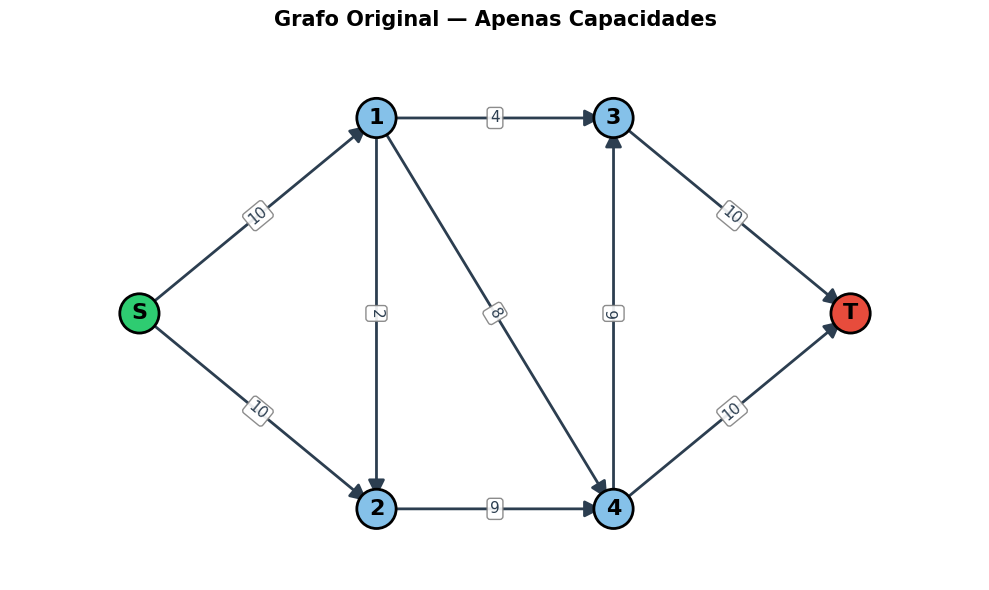

In [24]:
# Célula 6 — Grafo Inicial (antes da execução)
''' 
    Plot do grafo original, mostrando apenas as capacidades e sem destacar nenhum caminho.
'''
n = len(capacidade)
fluxo_zero = [[0] * n for _ in range(n)]

plot_grafo(
    capacidade, fluxo_zero,
    caminho=None,
    titulo="Grafo Original — Apenas Capacidades",
    mostrar_fluxo=False
)


In [25]:
# Célula 7 — Execução do Algoritmo
'''
    Executa o algoritmo de Edmonds-Karp e imprime o fluxo máximo e o número de caminhos aumentantes encontrados.'''

origem = 0
destino = 5

fluxo_max, fluxo_final, steps = edmonds_karp_steps(capacidade, origem, destino)

print(f"Fluxo máximo: {fluxo_max}")
print(f"Caminhos aumentantes encontrados: {len(steps)}")


Fluxo máximo: 19
Caminhos aumentantes encontrados: 4



-->x<---->x<---->x<---->x<---->x<---->x<---->x<---->x<---->x<---->x<--
  Iteração 4 de 4
  Caminho:  S → 2 → 4 → 3 → T
  Gargalo:  5
  Fluxo acumulado:  19
-->x<---->x<---->x<---->x<---->x<---->x<---->x<---->x<---->x<---->x<--


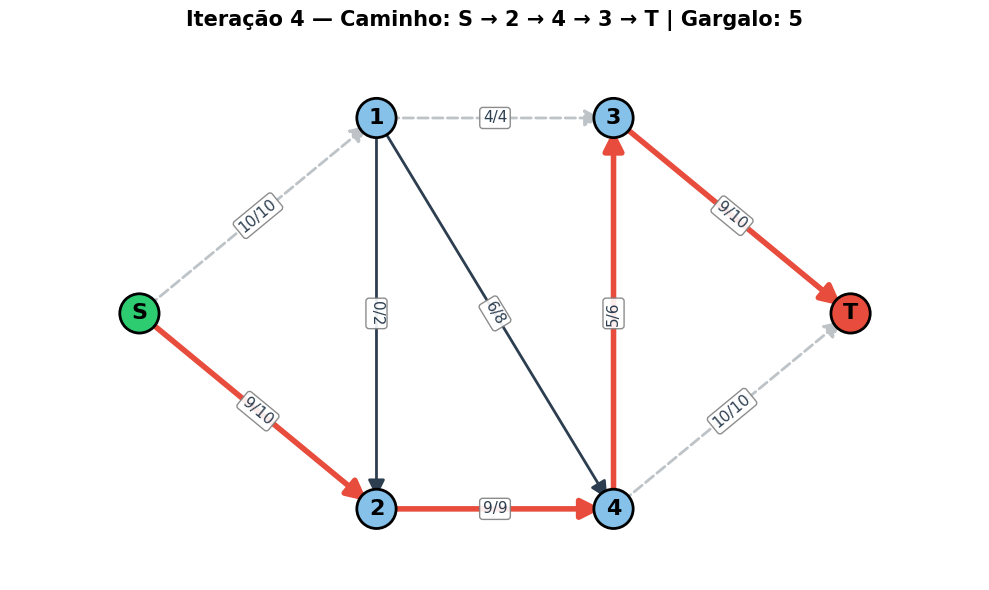

In [26]:
# Célula 8 — Animação Passo a Passo
'''
    Animação que percorre cada passo do algoritmo, mostrando o caminho aumentante encontrado, o gargalo e o fluxo acumulado até aquele ponto. Cada iteração é exibida por alguns segundos antes de passar para a próxima.
    
'''

for i, step in enumerate(steps):
    '''
    Para cada passo do algoritmo, limpa a saída anterior e exibe o caminho aumentante encontrado, o gargalo e o fluxo acumulado. O grafo é atualizado para destacar o caminho aumentante e as arestas saturadas. Cada iteração é exibida por alguns segundos antes de passar para a próxima.
    '''
    
    clear_output(wait=True)

    caminho = step["caminho"]
    gargalo = step["gargalo"]
    fluxo_atual = step["fluxo"]
    total = step["fluxo_total"]
    nos_caminho = [NODE_LABELS[u] for u, v in caminho] + [NODE_LABELS[caminho[-1][1]]]
    caminho_str = " → ".join(nos_caminho)

    print(f"\n{'-->x<--' * 10}")
    print(f"  Iteração {i + 1} de {len(steps)}")
    print(f"  Caminho:  {caminho_str}")
    print(f"  Gargalo:  {gargalo}")
    print(f"  Fluxo acumulado:  {total}")
    print(f"{'-->x<--' * 10}")

    plot_grafo(
        capacidade, fluxo_atual, caminho,
        titulo=f"Iteração {i + 1} — Caminho: {caminho_str} | Gargalo: {gargalo}"
    )

    time.sleep(3)



-->x<---->x<---->x<---->x<---->x<---->x<---->x<---->x<---->x<---->x<--
  FLUXO MÁXIMO: 19
  Iterações: 4
-->x<---->x<---->x<---->x<---->x<---->x<---->x<---->x<---->x<---->x<--



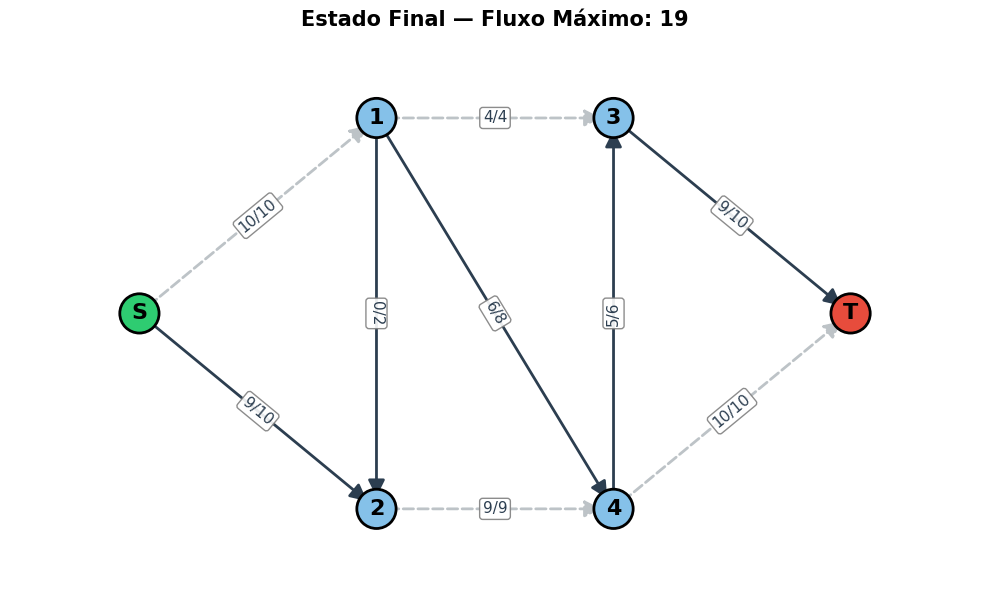

In [27]:
# Célula 9 — Resultado Final

clear_output(wait=True)

print(f"\n{'-->x<--' * 10}")
print(f"  FLUXO MÁXIMO: {fluxo_max}")
print(f"  Iterações: {len(steps)}")
print(f"{'-->x<--' * 10}\n")

plot_grafo(
    capacidade, fluxo_final, caminho=None,
    titulo=f"Estado Final — Fluxo Máximo: {fluxo_max}"
)


# Resultado final esperado

Fluxo máximo: 19

---